In [1]:
import numpy as np
import pandas as pd
import os 
import sys

import preprocess.spikesort_utils as sort_utils
sys.path.append("..//neural")
from format_waveform_data import map_contacts_to_intan
sys.path.append("..//utils")
import load_matlab_data

import spikeinterface as si # core only
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.exporters as sexp

from spikeinterface.core.motion import Motion
from spikeinterface.sortingcomponents.motion import interpolate_motion
from spikeinterface.sortingcomponents.matching import find_spikes_from_templates

from probeinterface import get_probe

import dartsort

import probeinterface.plotting as prb_plotting
import spikeinterface.widgets as sw
import dartsort.vis as dartvis
import matplotlib.pyplot as plt

C:\Users\Isabel\miniconda3\envs\spike_sort\Lib\site-packages\dartsort\clustering\mixture.py:108: UserWarning: Your PyTorch version (2.5.1+cu121) is supported by dartsort, but dartsort would be faster if you had >= 2.6.0.
  warnings.warn(


### Spike sort a stim session and match spontaneous templates to antidromic hash.
- find stim times and remove stim events
- preprocess (bandpass, CMR)
- motion correct
- split the data into spontaneous-only and antidromic hash chunks using stim times
- sort spontaneous-only data w/ kilosort
- match templates to antidromic hash with built-in SI template matching (wobble or circus)
- concatenate spike times, labels, scores and export for phy

In [2]:
''' File paths '''
root_dir = "C:/Users/Isabel/Documents/data_temp/"

# session params
bird_id = "SLV132"
session_id = "250310"
ephys_id = "SLV132_250310_122522"

# path to .rhd intan file
intan_folder = f"{root_dir}{bird_id}_{session_id}/{ephys_id}/"

# path to various info files
map_file_path = 'Z:/Isabel/ephys/SILICON PROBE MAP H10_spikesort.xlsx'
stim_data_file = f"{intan_folder}raw_ephys_output/stim_t_all.npy"

# output folders for kilosort, dartsort, and phy
temp_dir = f"{intan_folder}/stim_exp/temp_dir/"
if os.path.isdir(temp_dir):
    print('output folder exists')
else:
    os.mkdir(temp_dir)
ks_folder = f"{intan_folder}stim_exp/kilosort_si/"
match_folder = f"{intan_folder}stim_exp/matching/"
if os.path.isdir(match_folder):
    print('output folder exists')
else:
    os.mkdir(match_folder)

output folder exists


In [3]:
''' Load the recording file '''
# raw neural data
recording = se.read_intan(f"{intan_folder}info.rhd", stream_id='0')
fs = recording.get_sampling_frequency()

In [4]:
''' Add the probe map and check channel layout '''
# load the probe layout & map to intan
probe = get_probe(manufacturer="cambridgeneurotech", probe_name="ASSY-236-H10")
contact_sort, ch_names, shank_idx = map_contacts_to_intan(probe, map_file_path)
probe = probe.get_slice(contact_sort)

# set the channel indices in the probe object
n_channels = contact_sort.shape[0]
probe.set_device_channel_indices(np.arange(n_channels))

# add the probe map
recording = recording.set_probe(probe)
recording.set_property("channel_name", ch_names)
recording.set_property("group", shank_idx)

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

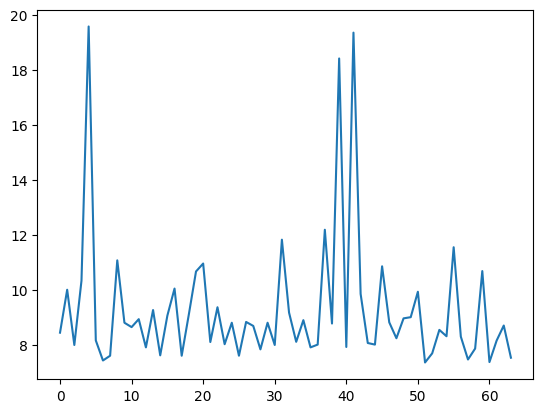

In [5]:
# check for noisy channels
noise_level = si.get_noise_levels(spre.common_reference(spre.highpass_filter(recording)))
plt.plot(noise_level)

In [6]:
# set noise threshold and remove noisy channels
noise_thresh = 16
keep_ch_idx = noise_level < noise_thresh
recording = recording.select_channels(recording.channel_ids[keep_ch_idx])

In [7]:
# sanity check and channel count
print(recording.get_num_channels())
print(recording.get_property("group").shape)
print(recording.get_property("channel_name").shape)
print(recording.get_channel_locations().shape)

61
(61,)
(61,)
(61, 2)


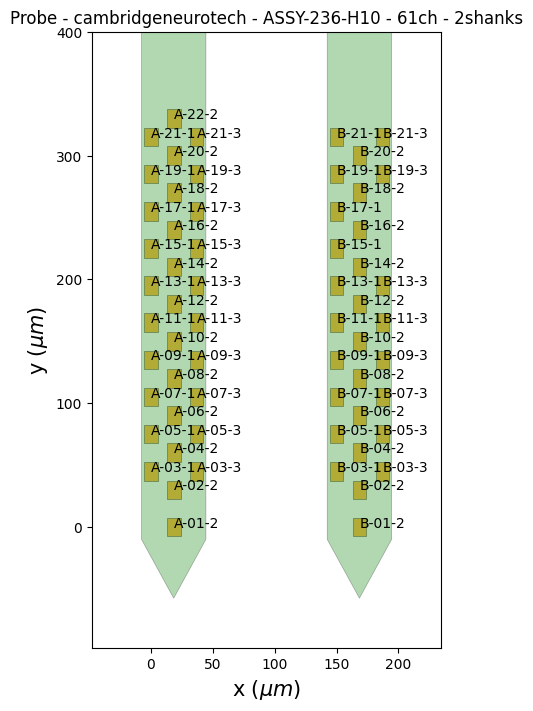

In [8]:
# reset the probe device indices
probe = recording.get_probe()
probe.set_device_channel_indices(np.arange(probe.get_contact_count()))

# visualize to check
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
prb_plotting.plot_probe(probe, ax=ax)
ylims = ax.get_ylim()
ax.set_ylim(ylims[0], 400)
for pos, ch_name in zip(probe.contact_positions, recording.get_property("channel_name")):
    ax.text(pos[0], pos[1], ch_name)

In [9]:
recording = recording.set_probe(probe)
assert (recording.get_num_channels() == recording.get_probe().get_contact_count())

### Find and remove stim events

In [10]:
# load the saved stim times
stim_t_samples = np.load(stim_data_file)
stim_t_samples = np.squeeze(stim_t_samples.astype(int))

In [11]:
# remove stim events + buffer - fit baseline DC with a spline to avoid disjointed concatenation
rec_no_stim, mask_starts, mask_duration = sort_utils.remove_stim_events_spline_dc(recording, stim_t_samples, temp_dir,
                                                                                  buffer=10, stim_dur=200e-6,
                                                                                  dc_win_sec=0.2e-3,
                                                                                  spike_kernel_ms=2.0,
                                                                                  apply_win_sec=120e-3,
                                                                                  knot_one_ms=0.5,
                                                                                  n_log_knots=18,
                                                                                  min_dc_uv=5.0)

### Prepreprocess (Bandpass filter, common median referencing, motion correction)

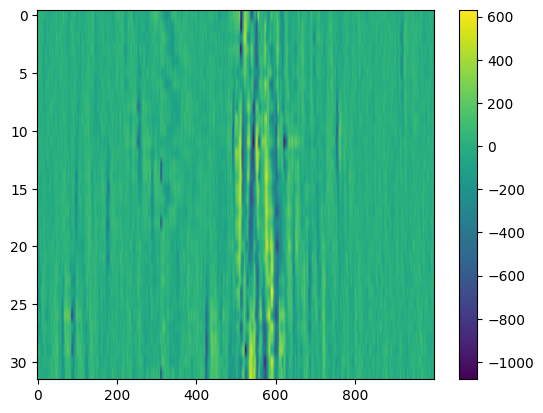

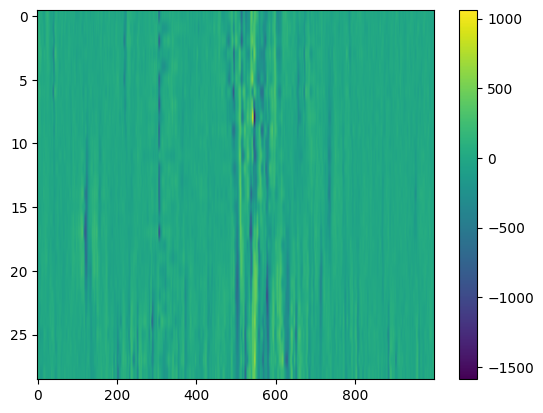

In [12]:
# filter and CMR
rec_filt_cmr = sort_utils.ks4_preprocess(rec_no_stim, filt=True, cmr=True, whiten=False)

# visualize each shank around a stim event to check for clean removal
split_rec = rec_filt_cmr.split_by("group")
plt.imshow(spre.depth_order(split_rec[0]).get_traces(0, mask_starts[9]-500, mask_starts[9]+500).T, aspect='auto')
plt.colorbar()
plt.show()

plt.imshow(spre.depth_order(split_rec[1]).get_traces(0, stim_t_samples[9]-500, stim_t_samples[9]+500).T, aspect='auto')
plt.colorbar()
plt.show()

In [13]:
# estimate drift
if os.path.isdir(f'{intan_folder}stim_exp/motion_estimate'):
    # load pre-existing motion info
    motion = Motion.load(f'{intan_folder}stim_exp/motion_estimate')
    motion_info = np.load(f'{intan_folder}stim_exp/motion_info.npz')
else:
    # compute motion estimate and info
    motion, motion_info = spre.compute_motion(
        rec_filt_cmr,
        preset="nonrigid_accurate",
        output_motion_info=True,
    )
    
    # save for later
    motion.save(f'{intan_folder}stim_exp/motion_estimate')
    np.savez(f'{intan_folder}stim_exp/motion_info.npz', 
             peaks=motion_info["peaks"], peak_locations=motion_info["peak_locations"])

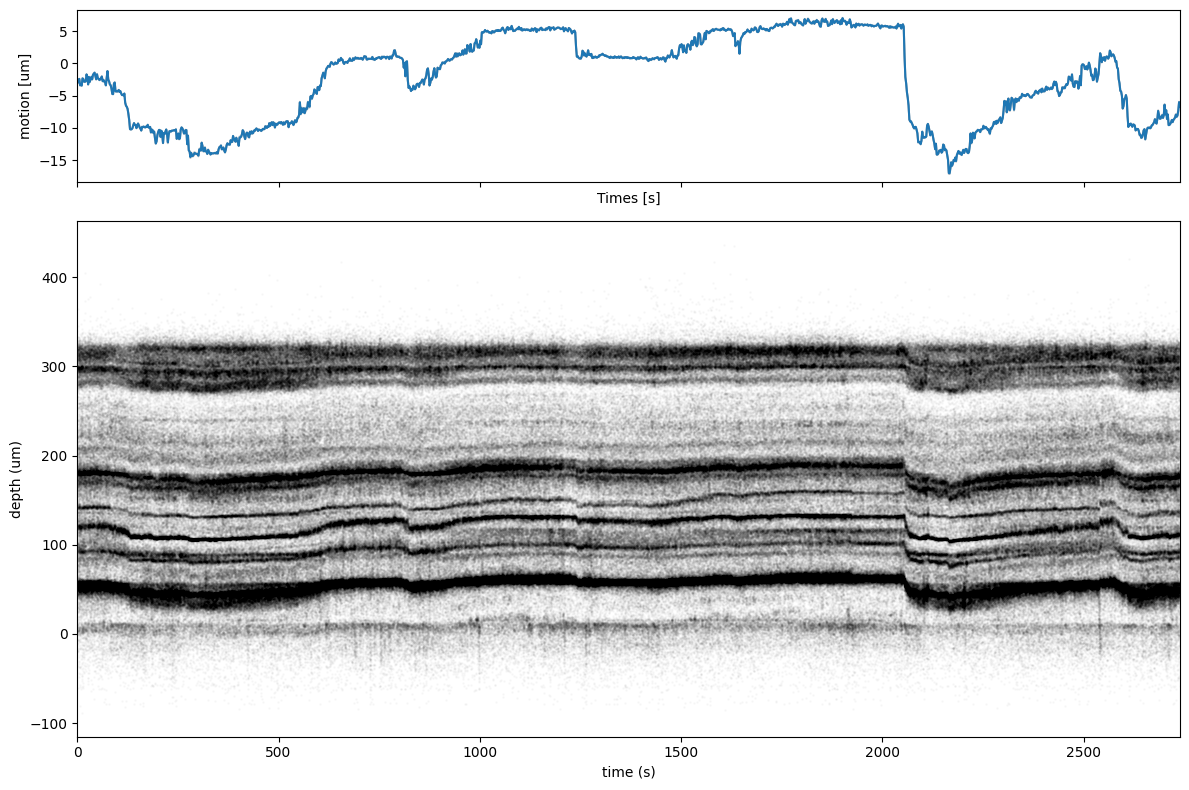

In [14]:
# data params
peak_times = (motion_info["peaks"]["sample_index"]/fs)
depths = motion_info["peak_locations"]["y"]

# fig params
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                               gridspec_kw={"height_ratios": [1, 3]})

# motion estimate
sw.plot_motion(motion, ax=ax0)

# peak localization scatter
ax1.scatter(peak_times, depths, c='k', s=1, alpha=0.02)
ax1.set_xlabel("time (s)")
ax1.set_ylabel("depth (um)")
ax0.set_xlim(0, rec_filt_cmr.get_num_frames()/rec_filt_cmr.get_sampling_frequency())

plt.tight_layout()
plt.show()

In [15]:
# interpolate motion
rec_mc = interpolate_motion(rec_filt_cmr, motion)

### Separate hash period from the rest of the recording

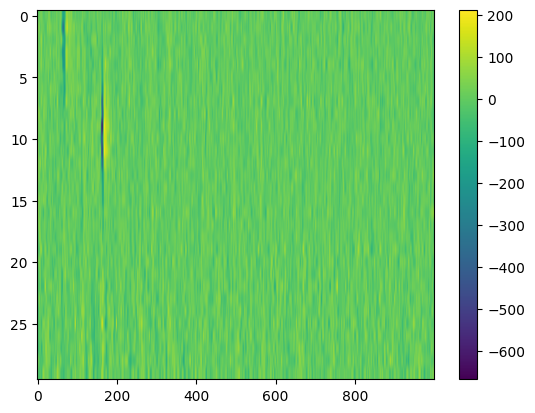

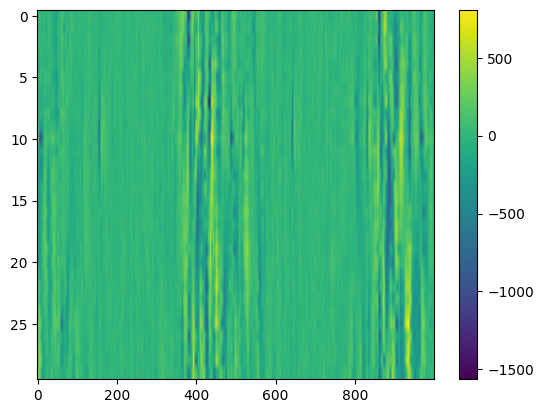

In [18]:
# define the hash window
start_hash = 5e-3
end_hash = 15e-3
pad_t = 3e-3

# separate the recordings
recordings, maps = sort_utils.split_hash_spontaneous(rec_mc, mask_starts, mask_duration, 
                                                     start_chunk_t=start_hash, end_chunk_t=end_hash, 
                                                     pad_t=pad_t)

# plot to check
split_rec = recordings['pre_stim'].split_by("group")
plt.imshow(spre.depth_order(split_rec[0]).get_traces(0, mask_starts[1]-mask_duration, mask_starts[1] - mask_duration + 1000).T, aspect='auto')
plt.colorbar()
plt.show()

split_rec = recordings['post_stim'].split_by("group")
plt.imshow(spre.depth_order(split_rec[0]).get_traces(0, 1200, 2200).T, aspect='auto')
plt.colorbar()
plt.show()

In [ ]:
# to parallelize processing
si.set_global_job_kwargs(
    n_jobs=8,
    chunk_duration="1s",
    progress_bar=True,
    mp_context="spawn",
)

In [19]:
# save as binary files for sorting and matching
rec_pre_stim = recordings['pre_stim'].save(format="binary", folder=f"{intan_folder}stim_exp/pre_stim_binary", n_jobs=8)
rec_post_stim = recordings['post_stim'].save(format="binary", folder=f"{intan_folder}stim_exp/post_stim_binary")

write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=6.64 MiB - total_memory=6.64 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization):   0%|          | 0/2730 [00:00<?, ?it/s]

write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=6.64 MiB - total_memory=6.64 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization):   0%|          | 0/16 [00:00<?, ?it/s]

### Sort spontaneous pre-stim spiking with Kilosort

In [20]:
# sort
sort_pre_stim = ss.run_sorter(sorter_name="kilosort4", 
                              recording=rec_pre_stim, 
                              folder=f"{ks_folder}", 
                              torch_device='cuda', 
                              skip_kilosort_preprocessing=False,
                              nblocks=0,
                              verbose=True)

kilosort.run_kilosort:  
kilosort.run_kilosort: Computing preprocessing variables.
kilosort.run_kilosort: ----------------------------------------
kilosort.run_kilosort: N samples: 81894606
kilosort.run_kilosort: N seconds: 2729.8202
kilosort.run_kilosort: N batches: 1365
kilosort.run_kilosort: Preprocessing filters computed in 0.96s; total 0.96s
kilosort.run_kilosort:  
kilosort.run_kilosort: Resource usage after preprocessing
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort: CPU usage:     5.00 %
kilosort.run_kilosort: Mem used:     32.20 %     |      20.33 GB
kilosort.run_kilosort: Mem avail:    42.81 / 63.14 GB
kilosort.run_kilosort: ------------------------------------------------------
kilosort.run_kilosort: GPU usage:    `conda install pynvml` for GPU usage
kilosort.run_kilosort: GPU memory:   10.21 %     |      1.63   /    15.99 GB
kilosort.run_kilosort: Allocated:     0.05 %     |      0.01   /    15.99 GB
kilosort.run_kilos

kilosort4 run time 242.75s


### Match templates to the post-stim period
todo below code is still mostly copied from Claude need to check

**arguments for method=’circus-omp’**
amplitude : tuple
    (Minimal, Maximal) amplitudes allowed for every template
max_failures : int
    Stopping criteria of the OMP algorithm, as number of retry while updating amplitudes
rank : int, default: 5
    Number of components used internally by the SVD
vicinity : int
    Size of the area surrounding a spike to perform modification (expressed in terms of template temporal width)
ignore_inds : list
    List of template indices to ignore during the matching
precomputed : dict | None   
    If not None, a dict with precomputed values for the templates
engine : string in [“numpy”, “torch”, “auto”]. Default “auto”    
    The engine to use for the convolutions
torch_device : string in [“cpu”, “cuda”, None]. Default “cpu”   
    Controls torch device if the torch engine is selected
shared_memory : bool, default True   
    If True, the overlaps are stored in shared memory, which is more efficient when using numerous cores

In [21]:
# select the "good" units
clu_group = sort_utils.get_ks_cluster_groups(f"{ks_folder}")
good_unit_ids = [uid for uid, grp in zip(sort_pre_stim.unit_ids, clu_group) if grp == "good"]
good_units_sort = sort_pre_stim.select_units(good_unit_ids)

In [22]:
# try "circus-omp" first; "wobble" is a good cross-check for tight/sub-sample collisions
matching_method = "circus-omp"

# get the templates
analyzer = si.create_sorting_analyzer(
    sorting=good_units_sort,
    recording=rec_pre_stim,
    format="binary_folder",
    folder=f"{match_folder}/{matching_method}/analyzer_templates",
    sparse=True,
)
analyzer.compute("random_spikes", method="uniform", max_spikes_per_unit=500)
analyzer.compute("waveforms", ms_before=1.5, ms_after=4) # todo adjust?
analyzer.compute("templates", operators=["average"])

templates = analyzer.get_extension("templates").get_data(outputs="Templates")

# sanity check: num_units, num_samples, num_channels, sparsity
print(templates)  

estimate_sparsity (no parallelization):   0%|          | 0/2730 [00:00<?, ?it/s]

C:\Users\Isabel\miniconda3\envs\spike_sort\Lib\site-packages\spikeinterface\core\basesorting.py:384: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


compute_waveforms (no parallelization):   0%|          | 0/2730 [00:00<?, ?it/s]

Templates: 139 units - 165 samples - 58 channels 
sampling_frequency=30.00 kHz - ms_before=1.50 ms - ms_after=4.00 ms
Probe - 58ch - 2shanks


In [23]:
# Run template matching on the (padded) post-stim chunks
matched_spikes = find_spikes_from_templates(
    rec_post_stim,
    templates=templates,
    method=matching_method,
    n_jobs=8,
    chunk_duration="100ms",
    progress_bar=True,
    method_kwargs={
        "amplitudes" : [0.6, 1.5],
        "rank" : 8,
        "vicinity" : 3,
        "stop_criteria": "max_failures",
        "max_failures": 4,  # default = 5
    },
)

C:\Users\Isabel\miniconda3\envs\spike_sort\Lib\site-packages\spikeinterface\sortingcomponents\matching\main.py:56: UserWarning: The signature of find_spikes_from_templates() has changed, now job_kwargs are in separated dict and not flattenThis warning will raise an error in version 0.105.0
  warnings.warn(


find spikes (circus-omp) (workers: 8 processes spawn):   0%|          | 0/152 [00:00<?, ?it/s]

### Combine sorted and matched spikes into one spike train

In [24]:
# cluster_index indexes into templates.unit_ids (== good_unit_ids, in order)
post_stim_labels_raw = templates.unit_ids[matched_spikes["cluster_index"]]
post_stim_times_local = matched_spikes["sample_index"]

In [25]:
# map matched spikes back to global time & remove padding
post_stim_map = maps['post_stim']
post_stim_times_global = sort_utils.get_global_spikes(post_stim_times_local, post_stim_map)

keep_idx = sort_utils.remove_pad(
    post_stim_times_global,
    post_stim_map['true_global_starts'],
    post_stim_map['true_global_ends'],
)
post_stim_times = post_stim_times_global[keep_idx]
post_stim_labels = post_stim_labels_raw[keep_idx]

In [26]:
# map spontaneous spikes back to global time
pre_stim_map = maps['pre_stim']

pre_spike_vector = sort_pre_stim.to_spike_vector()
pre_spike_t_local = pre_spike_vector["sample_index"]
pre_stim_labels = sort_pre_stim.unit_ids[pre_spike_vector["unit_index"]]

pre_stim_times = sort_utils.get_global_spikes(pre_spike_t_local, pre_stim_map)

In [27]:
# concatenate spontaneous + matched spikes into one spike train
all_spike_t = np.concatenate([pre_stim_times, post_stim_times])
all_spike_labels = np.concatenate([pre_stim_labels, post_stim_labels])

# sort by time
sort_idx = np.argsort(all_spike_t)
all_spike_t = all_spike_t[sort_idx]
all_spike_labels = all_spike_labels[sort_idx]

In [28]:
# create a Spike Interface sorting object to export to Phy
fs = rec_pre_stim.get_sampling_frequency()
combined_sorting = si.NumpySorting.from_samples_and_labels(
    samples_list=[all_spike_t],
    labels_list=[all_spike_labels],
    sampling_frequency=fs,
)

In [29]:
# add the KS labels (good, mua...)
clu_group = sort_utils.get_ks_cluster_groups(f"{ks_folder}")  # aligned to sort_pre_stim.unit_ids
ks_label_map = dict(zip(sort_pre_stim.unit_ids, clu_group))
ks_labels_ordered = np.array([ks_label_map[uid] for uid in combined_sorting.unit_ids])

combined_sorting.set_property("KSLabel", ks_labels_ordered)

In [30]:
'''
Export results + post-process
- phy compatible format
- and/or SC automated curation method?
- ultimately match key files to existing data (e.g. wfStruct)
'''
# create a sorting analyzer
analyzer = si.create_sorting_analyzer(
    sorting=combined_sorting,
    recording=recording,
    folder="analyzer",
)

# compute things for phy
analyzer.compute(['random_spikes', 'waveforms', 'templates', 'noise_levels'])
_ = analyzer.compute('principal_components', n_components = 5, mode="by_channel_local")
_ = analyzer.compute("spike_amplitudes")
_ = analyzer.compute("unit_locations")
_ = analyzer.compute("template_similarity")

estimate_sparsity (no parallelization):   0%|          | 0/2740 [00:00<?, ?it/s]

compute_waveforms (no parallelization):   0%|          | 0/2740 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

Fitting PCA:   0%|          | 0/251 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/251 [00:00<?, ?it/s]

spike_amplitudes (no parallelization):   0%|          | 0/2740 [00:00<?, ?it/s]

C:\Users\Isabel\miniconda3\envs\spike_sort\Lib\site-packages\spikeinterface\postprocessing\template_similarity.py:345: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  overlapping_ids = overlapping_j_list[i]


In [31]:
# export to phy
sexp.export_to_phy(analyzer, 
                   output_folder=f'{match_folder}/{matching_method}/phy_output',
                   additional_properties=["KSLabel"])

write_binary_recording (workers: 8 processes spawn):   0%|          | 0/2740 [00:00<?, ?it/s]

extract PCs (workers: 8 processes spawn):   0%|          | 0/2740 [00:00<?, ?it/s]

Run:
phy template-gui  C:\Users\Isabel\Documents\data_temp\SLV132_250310\SLV132_250310_122522\stim_exp\matching\circus-omp\phy_output\params.py


In [32]:
# extract and save spike positions
spike_positions = sort_utils.get_spike_positions(analyzer, subsample=False)
np.save(f'{match_folder}/{matching_method}/phy_output/spike_positions.npy', spike_positions)

spike_locations (no parallelization):   0%|          | 0/2740 [00:00<?, ?it/s]

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/Isabel/Documents/data_temp/SLV132_250310/SLV132_250310_122522/stim_exp/matching//circus-omp/.phy/spike_positions.npy'